## Libraries

In [17]:
import tensorflow as tf
import os
import cv2
import matplotlib.pyplot as plt
import shutil
import random

random.seed(7)

## Preparación del Entorno

En esta sección importamos las librerías necesarias para el desarrollo del proyecto.

> En este proyecto se utilizo un virtual enviroment, creado con:
>```bash
>virtualenv .venv
>```
> Luego se activó con:
>```bash
>.venv/Scripts/activate
>```
>Se adjunta `requirements.txt` con las librerías utilizadas en el proyecto.

In [1]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 7A02-6FBE

 Directory of c:\Users\moise\Documents\0001_MADI\DeepLearning\Notebooks\MultipleDetection-PCB

18/12/2025  09:33    <DIR>          .
18/12/2025  09:45    <DIR>          ..
18/12/2025  09:23               156 custom.yaml
18/12/2025  09:44    <DIR>          Data
18/12/2025  09:23    <DIR>          Examples
18/12/2025  09:43         1.045.645 PCB - Det.ipynb
18/12/2025  09:33           153.886 PCB - Det.md
               3 File(s)      1.199.687 bytes
               4 Dir(s)  393.216.593.920 bytes free


In [3]:
PATH = 'Data/'
#BASE_PATH = '/content/sample_data/'
#DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/03b - MultipleDetection-PCB/'

In [ ]:
#!unzip -q '/content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/03b - MultipleDetection-PCB/Data/Original Images.zip' -d '/content/sample_data/Data'

YOLO ANNOTATIONS FORMAT: class, x_center, y_center, width, height

DATA FORMAT IN THE FILES PROVIDED: x_min, y_min, x_max, y_max, class

In [7]:
# OBTAIN PATH TO ALL OBJECTS

path_origin = PATH+'Original Images'

items_paths = []

groups_folders = os.listdir(path_origin)

for folder in groups_folders:
    subfolders = os.listdir(os.path.join(path_origin, folder))

    for subfolder in subfolders:
        items = os.listdir(os.path.join(os.path.join(path_origin, folder), subfolder))

        for item in items:
            items_paths.append(os.path.join(os.path.join(os.path.join(path_origin, folder), subfolder), item))

print(len(items_paths))

4501


In [8]:
# SPLIT BETWEEN ANNOTATIONS AND IMAGES

annotations_path = []
images_path = []

for item_path in items_paths:
    if '_not' in item_path:
        annotations_path.append(item_path)

    if '_test' in item_path:
        images_path.append(item_path)

In [9]:
# CHECK LENGTH

print(len(images_path))
print(len(annotations_path))

1500
1500


In [10]:
images_path[50]

'Data/Original Images\\group00041\\00041\\00041050_test.jpg'

In [19]:
# SPLIT THE PATH TO OBTAIN ONLY THE IMAGE NAME

words = images_path[50].split('\\')
words[-1]


'00041050_test.jpg'

In [20]:
# OBTAIN ONLY THE CODE FOR THE IMAGE

image_name = words[-1].replace('_test.jpg', '')
image_name

'00041050'

In [21]:
# SEARCH FOR THE ANNOTATION OF THE IMAGE

for annotation in annotations_path:

    if image_name in annotation:
        break
annotation

'Data/Original Images\\group00041\\00041_not\\00041050.txt'

In [22]:
# READ TH FILE

with open(annotation, 'r') as content:
    details = content.readlines()

details

['372 310 433 340 1\n',
 '464 153 514 179 2\n',
 '455 331 488 357 3\n',
 '485 328 518 359 3\n',
 '543 158 579 188 4\n',
 '388 387 418 424 6\n']

In [23]:
# CLASS DICTIONARY FROM GITHUB (https://github.com/tangsanli5201/DeepPCB)

dict_classes = {1: 'open', 2: 'short', 3: 'mousebite', 4: 'spur', 5: 'copper', 6: 'pin-hole'}

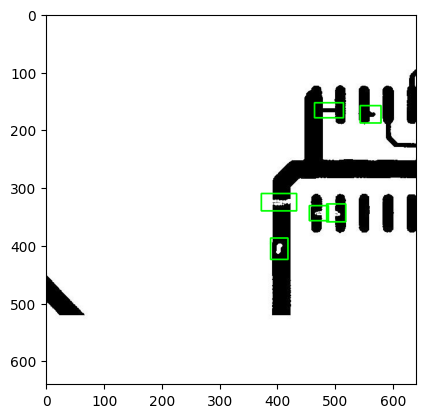

In [24]:
# DRAW ANNOTATIONS IN THE IMAGE

image = images_path[50]
label = details

image = cv2.imread(image)

for detail in details:

    splitted = detail.split()
    x1 = int(splitted[0])
    x2 = int(splitted[2])
    y1 = int(splitted[1])
    y2 = int(splitted[3])

    rectangle_image = cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(rectangle_image)

In [31]:
# AS WE CHECK THE FORMAT OF THE ANNOTATION, LET'S TRANSLATE IT TO YOLO FORMAT

def to_yolo(image_path, annotations_path, folder_path):

    yolo_out = []

    image = cv2.imread(image_path)
    h, w, c = image.shape

    # Usar os.path.basename en lugar de split manual
    image_name = os.path.basename(image_path).replace('_test.jpg', '')

    for annotation in annotations_path:

        if image_name in annotation:
            break

    with open(annotation, 'r') as content:
        details = content.readlines()

    for detail in details:

        splitted = detail.split()
        x1 = int(splitted[0])
        x2 = int(splitted[2])
        y1 = int(splitted[1])
        y2 = int(splitted[3])
        label = int(splitted[4])-1 # CLASSES STARTS WITH 0 IN YOLO

        x_center = (x2 + x1) / (2*w)
        y_center = (y2 + y1) / (2*h)
        width = (x2-x1) / w
        height = (y2-y1) / h

        yolo_out.append([label, x_center, y_center, width, height])

    # Usar os.path.join para las rutas
    shutil.copy(image_path, os.path.join(folder_path, 'images', image_name + '.jpg'))

    with open(os.path.join(folder_path, 'labels', image_name + '.txt'), 'w') as archivo:
        for line in yolo_out:
            for w in line:
                archivo.write(str(w))
                archivo.write(' ')
            archivo.write('\n')

    return yolo_out

In [32]:
total_images = len(images_path)

train_number = int(total_images * 0.7)

train_images = random.sample(images_path, train_number)
val_images = [element for element in images_path if element not in train_images]

In [33]:
os.makedirs(PATH+'train/images', exist_ok=True)
os.makedirs(PATH+'train/labels', exist_ok=True)
os.makedirs(PATH+'val/images', exist_ok=True)
os.makedirs(PATH+'val/labels', exist_ok=True)

for image in train_images:
    to_yolo(image, annotations_path, PATH+'train')

for image in val_images:
    to_yolo(image, annotations_path, PATH+'val')

# YOLO TRAIN

In [34]:
import torch
torch.cuda.is_available()

True

In [35]:
# copy configuration file
shutil.copy("custom.yaml", PATH)

'Data/custom.yaml'

In [36]:
!pip install ultralytics

from ultralytics import YOLO

In [38]:
model_p = YOLO("yolov8n.pt")
model_p.train(data="custom.yaml", epochs=100, imgsz=640, batch=4, workers=1)

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.234  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002775365C1D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

In [ ]:
from google.colab import files

# no funciona con zip: A UTF-8 locale is required. Got ANSI_X3.4-1968
#!zip -r 'train.zip' '/content/runs/detect/train'

shutil.make_archive("train", 'zip', '/content/runs/detect/train')
files.download("train.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Training Evaluation

In [39]:
RUNS_PATH = 'detect/'

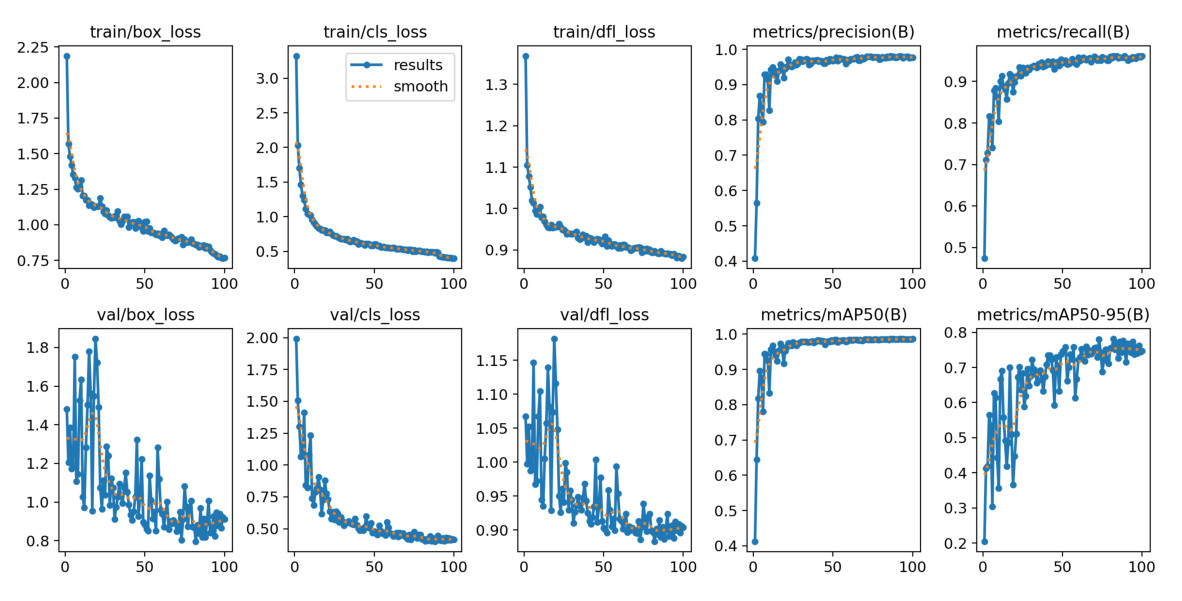

In [41]:
metrics = cv2.imread(RUNS_PATH+'train2/results.png')
metrics = cv2.cvtColor(metrics, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,12))
plt.imshow(metrics)
plt.axis('off')
plt.show()

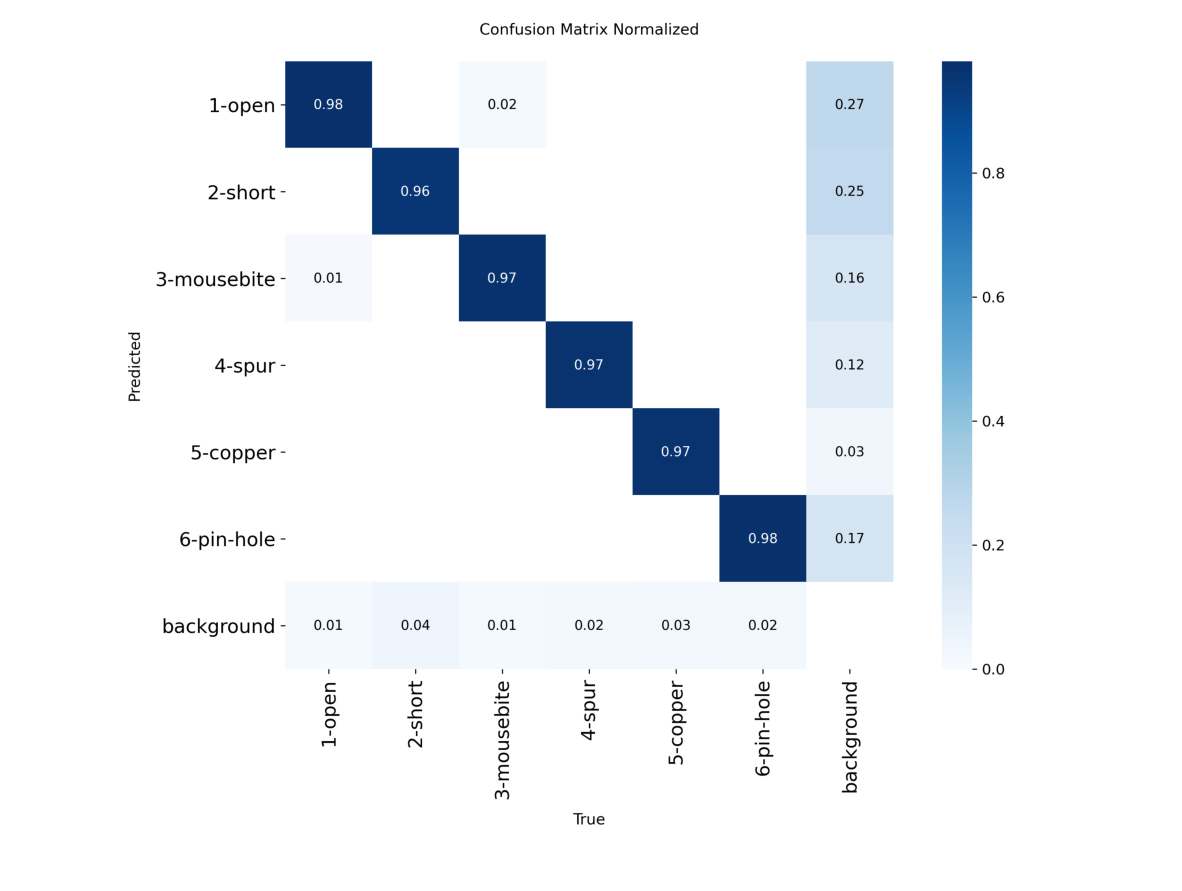

In [42]:
metrics = cv2.imread(RUNS_PATH+'train2/confusion_matrix_normalized.png')
metrics = cv2.cvtColor(metrics, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,12))
plt.imshow(metrics)
plt.axis('off')
plt.show()

## Model Inference

In [45]:
load_model = YOLO(RUNS_PATH+'train2/weights/best.pt')

path_1 = PATH+'val/images/00041000.jpg'
path_2 = PATH+'val/images/12100199.jpg'

predict_1 = load_model.predict(path_1)
predict_2 = load_model.predict(path_2)


image 1/1 c:\Users\moise\Documents\0001_MADI\DeepLearning\Notebooks\MultipleDetection-PCB\Data\val\images\00041000.jpg: 640x640 1 1-open, 1 2-short, 1 3-mousebite, 2 4-spurs, 2 5-coppers, 3 6-pin-holes, 22.4ms
Speed: 3.8ms preprocess, 22.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\moise\Documents\0001_MADI\DeepLearning\Notebooks\MultipleDetection-PCB\Data\val\images\12100199.jpg: 640x640 1 1-open, 2 2-shorts, 1 3-mousebite, 2 4-spurs, 1 5-copper, 1 6-pin-hole, 22.4ms
Speed: 4.1ms preprocess, 22.4ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


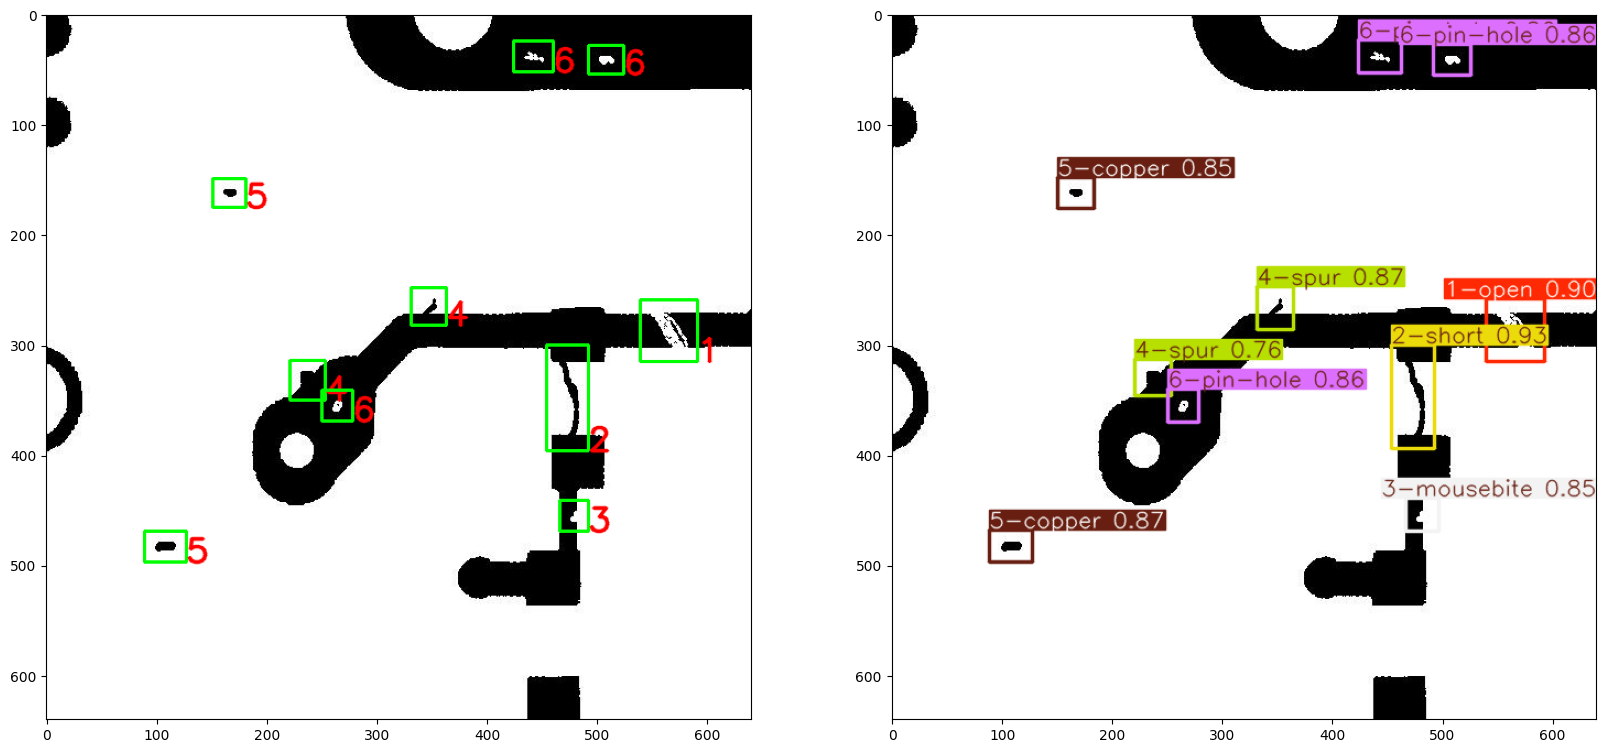

In [46]:
image = cv2.imread(path_1)
h,w,c = image.shape

with open(PATH+'val/labels/00041000.txt', 'r') as file:
    details = file.readlines()

for detail in details:

    splitted = detail.split()
    xc = int(float(splitted[1])*w)
    yc = int(float(splitted[2])*h)
    wy = int((float(splitted[3])*w)/2)
    hy = int((float(splitted[4])*h)/2)
    label = str(int(splitted[0])+1)

    rectangle_image = cv2.rectangle(image, (xc - wy,yc - hy), (xc + wy,yc + hy), (0,255,0), 2)
    cv2.putText(image, label, (xc+wy, yc+hy), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2, cv2.LINE_AA)

fig, axs = plt.subplots(1,2, figsize=(20,20))


axs[0].imshow(rectangle_image)
axs[1].imshow(predict_1[0].plot())
plt.show()

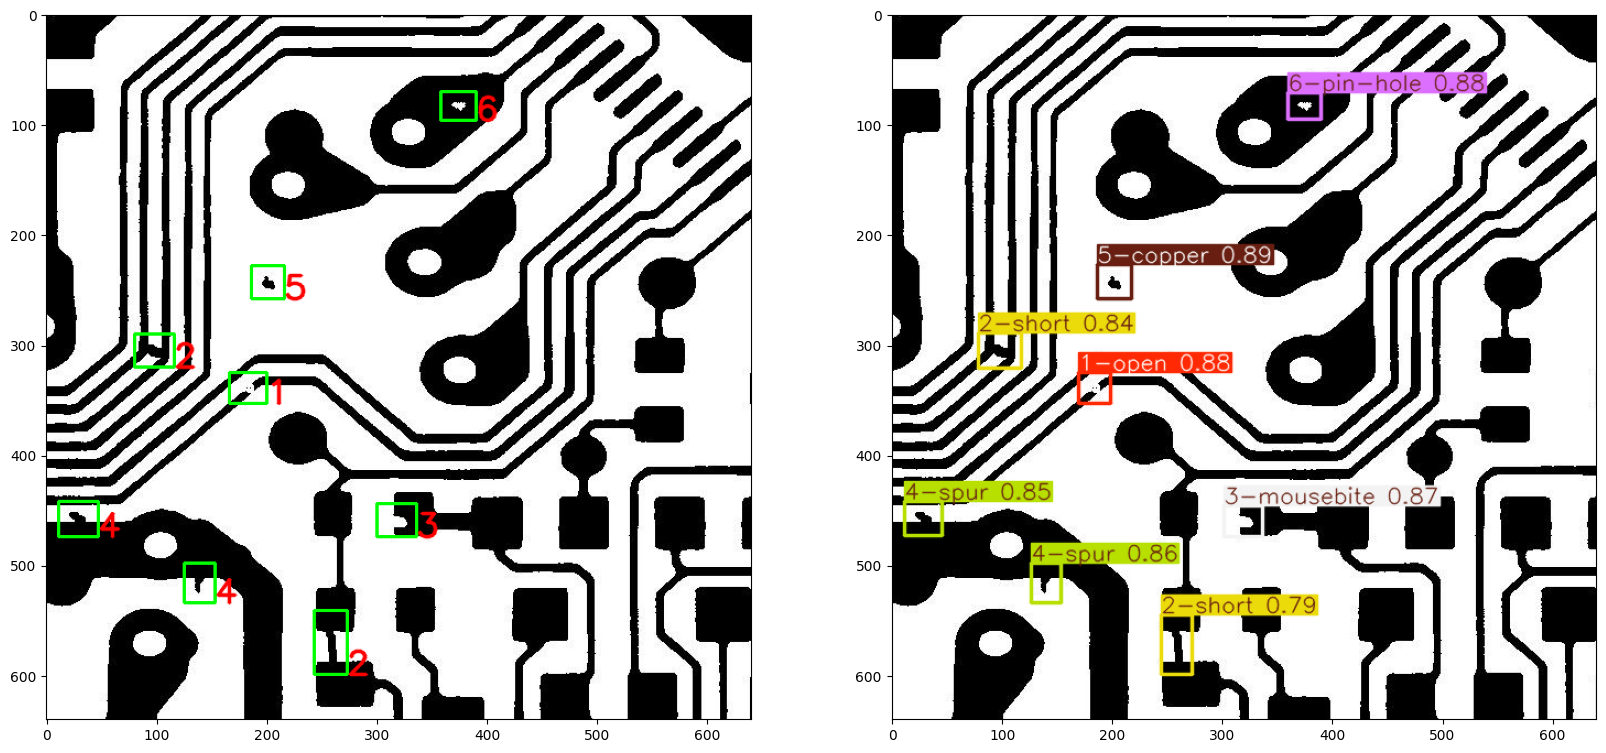

In [47]:
image = cv2.imread(path_2)
h,w,c = image.shape

with open(PATH+'val/labels/12100199.txt', 'r') as file:
    details = file.readlines()

for detail in details:

    splitted = detail.split()
    xc = int(float(splitted[1])*w)
    yc = int(float(splitted[2])*h)
    wy = int((float(splitted[3])*w)/2)
    hy = int((float(splitted[4])*h)/2)
    label = str(int(splitted[0])+1)

    rectangle_image = cv2.rectangle(image, (xc - wy,yc - hy), (xc + wy,yc + hy), (0,255,0), 2)
    cv2.putText(image, label, (xc+wy, yc+hy), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2, cv2.LINE_AA)

fig, axs = plt.subplots(1,2, figsize=(20,20))


axs[0].imshow(rectangle_image)
axs[1].imshow(predict_2[0].plot())
plt.show()

#Assignment

Objetivos:
- Plotear las diferentes métricas de train que aparecen en la carpeta de runs
- Explicar en una celda de texto cada métrica que se plotee
- Hacer el test de evaluacón en todas las fotos

Deadline:

---
# **ASSIGNMENT - Resolución Completa**

## Evaluación del Modelo YOLO para Detección de Defectos en PCB

**Objetivos:**
1. Plotear las diferentes métricas de train que aparecen en la carpeta de runs
2. Explicar en una celda de texto cada métrica que se plotee
3. Hacer el test de evaluación en todas las fotos

**Autor:** Moises Britez  
**Fecha:** Diciembre 2025

---

## 1. Funciones Auxiliares

Primero definimos funciones para autodetectar la carpeta de entrenamiento y procesar las métricas de manera automática.

In [58]:
import glob
import numpy as np
from pathlib import Path
from PIL import Image
import time

def find_latest_train_dir(runs_path='detect/'):
    """
    Busca automáticamente la carpeta de entrenamiento más reciente
    que contenga el archivo weights/best.pt
    
    Args:
        runs_path: Ruta base donde están los runs de YOLO
    
    Returns:
        train_dir: Ruta completa a la carpeta de entrenamiento
        weights_path: Ruta al mejor modelo entrenado
    """
    if not os.path.exists(runs_path):
        print(f" Warning: {runs_path} no existe")
        return None, None
    
    # Buscar todas las carpetas train*
    train_folders = glob.glob(os.path.join(runs_path, 'train*'))
    
    if not train_folders:
        print(f" Warning: No se encontraron carpetas de entrenamiento en {runs_path}")
        return None, None
    
    # Filtrar solo las que tengan weights/best.pt
    valid_folders = []
    for folder in train_folders:
        weights_file = os.path.join(folder, 'weights', 'best.pt')
        if os.path.exists(weights_file):
            valid_folders.append(folder)
    
    if not valid_folders:
        print(" Warning: No se encontraron carpetas con weights/best.pt")
        return None, None
    
    # Seleccionar la más reciente
    train_dir = max(valid_folders, key=os.path.getmtime)
    weights_path = os.path.join(train_dir, 'weights', 'best.pt')
    
    print(f" Carpeta de entrenamiento detectada: {train_dir}")
    print(f" Pesos del modelo: {weights_path}")
    
    return train_dir, weights_path


def plot_metric_image(image_path, title, figsize=(12, 8)):
    """
    Plotea una imagen de métrica si existe
    
    Args:
        image_path: Ruta a la imagen
        title: Título del gráfico
        figsize: Tamaño de la figura
    
    Returns:
        True si se ploteó exitosamente, False en caso contrario
    """
    if os.path.exists(image_path):
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=figsize)
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
        
        return True
    else:
        print(f"Warning: {os.path.basename(image_path)} no encontrado")
        return False


def plot_run_metrics(train_dir):
    """
    Plotea todas las métricas disponibles de un run de entrenamiento
    
    Args:
        train_dir: Ruta a la carpeta del run de entrenamiento
    """
    if train_dir is None:
        print("❌ No se puede plotear métricas: train_dir es None")
        return
    
    print("="*70)
    print("PLOTEANDO MÉTRICAS DE ENTRENAMIENTO")
    print("="*70)
    
    # Diccionario con las métricas a plotear
    metrics_to_plot = {
        'results.png': 'Métricas de Entrenamiento y Validación',
        'confusion_matrix.png': 'Matriz de Confusión',
        'confusion_matrix_normalized.png': 'Matriz de Confusión Normalizada',
        'BoxF1_curve.png': 'Curva F1-Score vs Confidence',
        'BoxPR_curve.png': 'Curva Precision-Recall',
        'BoxP_curve.png': 'Curva de Precisión vs Confidence',
        'BoxR_curve.png': 'Curva de Recall vs Confidence',
        'labels.jpg': 'Distribución de Labels en el Dataset'
    }
    
    plotted_count = 0
    for filename, title in metrics_to_plot.items():
        image_path = os.path.join(train_dir, filename)
        if plot_metric_image(image_path, title):
            plotted_count += 1
    
    print(f"\nTotal de métricas ploteadas: {plotted_count}/{len(metrics_to_plot)}")
    print("="*70)


print("Funciones auxiliares definidas correctamente")

Funciones auxiliares definidas correctamente


## 2. Detección Automática de la Carpeta de Entrenamiento

Buscamos automáticamente la carpeta donde se guardaron los resultados del entrenamiento.

In [59]:
# Detectar automáticamente la carpeta de entrenamiento
TRAIN_DIR, WEIGHTS_PATH = find_latest_train_dir(RUNS_PATH)

# Verificar que se encontró correctamente
if TRAIN_DIR:
    print(f"\n📁 Directorio de entrenamiento: {TRAIN_DIR}")
    print(f"Archivo de pesos: {WEIGHTS_PATH}")
    
    # Listar archivos disponibles
    print(f"\nArchivos disponibles en el directorio:")
    for file in sorted(os.listdir(TRAIN_DIR)):
        file_path = os.path.join(TRAIN_DIR, file)
        if os.path.isfile(file_path):
            size = os.path.getsize(file_path) / 1024  # KB
            print(f"   - {file:40s} ({size:>8.2f} KB)")
else:
    print(" ERROR: No se pudo detectar la carpeta de entrenamiento")

 Carpeta de entrenamiento detectada: detect\train2
 Pesos del modelo: detect\train2\weights\best.pt

📁 Directorio de entrenamiento: detect\train2
Archivo de pesos: detect\train2\weights\best.pt

Archivos disponibles en el directorio:
   - BoxF1_curve.png                          (  208.96 KB)
   - BoxPR_curve.png                          (  137.94 KB)
   - BoxP_curve.png                           (  145.97 KB)
   - BoxR_curve.png                           (  193.93 KB)
   - args.yaml                                (    1.63 KB)
   - confusion_matrix.png                     (  168.73 KB)
   - confusion_matrix_normalized.png          (  183.57 KB)
   - labels.jpg                               (  154.48 KB)
   - results.csv                              (   11.94 KB)
   - results.png                              (  306.74 KB)
   - train_batch0.jpg                         (  147.44 KB)
   - train_batch1.jpg                         (  136.34 KB)
   - train_batch2.jpg                         

## 3. Ploteo de Métricas de Entrenamiento

A continuación se muestran todas las métricas generadas durante el entrenamiento del modelo YOLO.

PLOTEANDO MÉTRICAS DE ENTRENAMIENTO


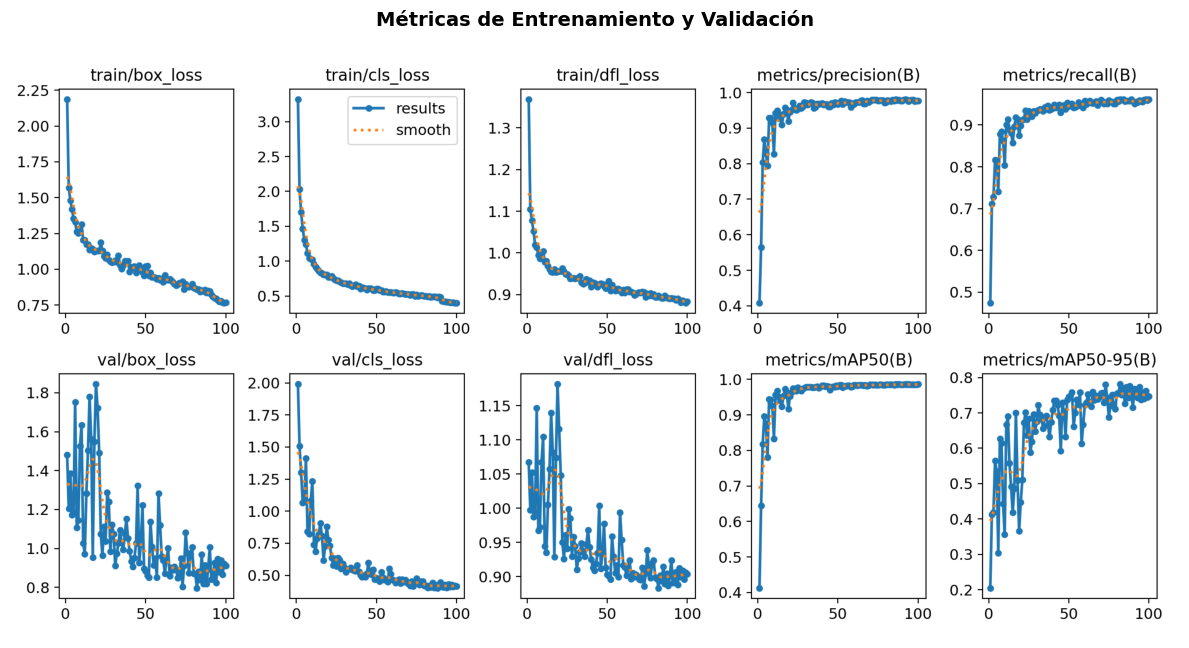

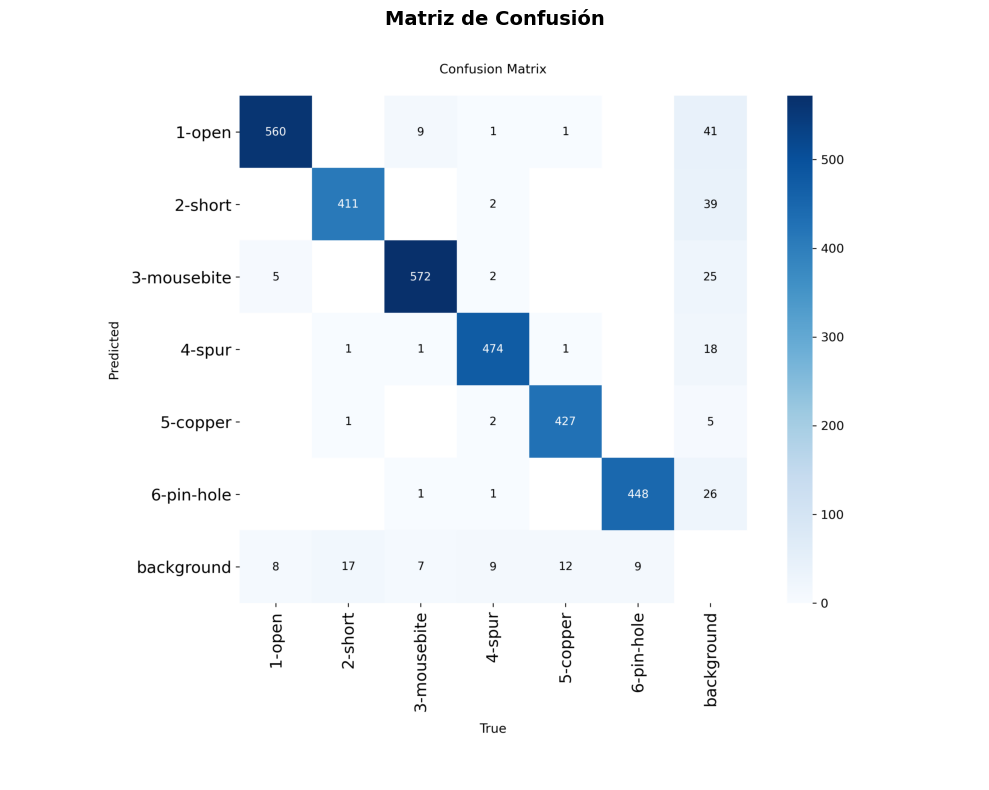

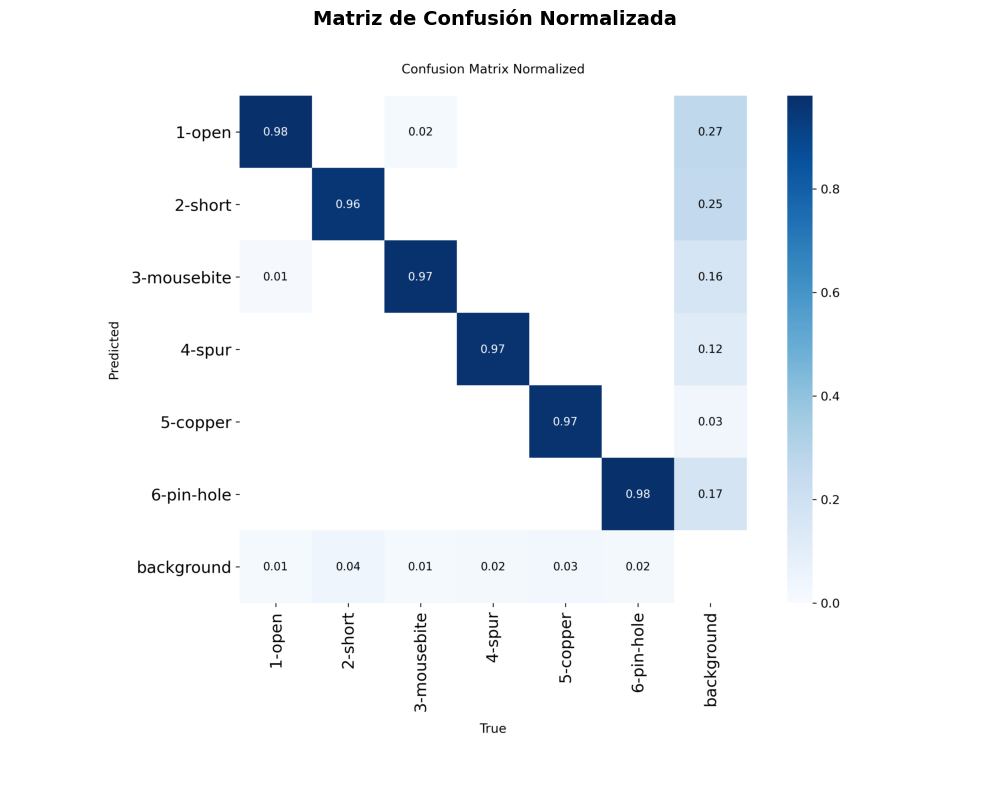

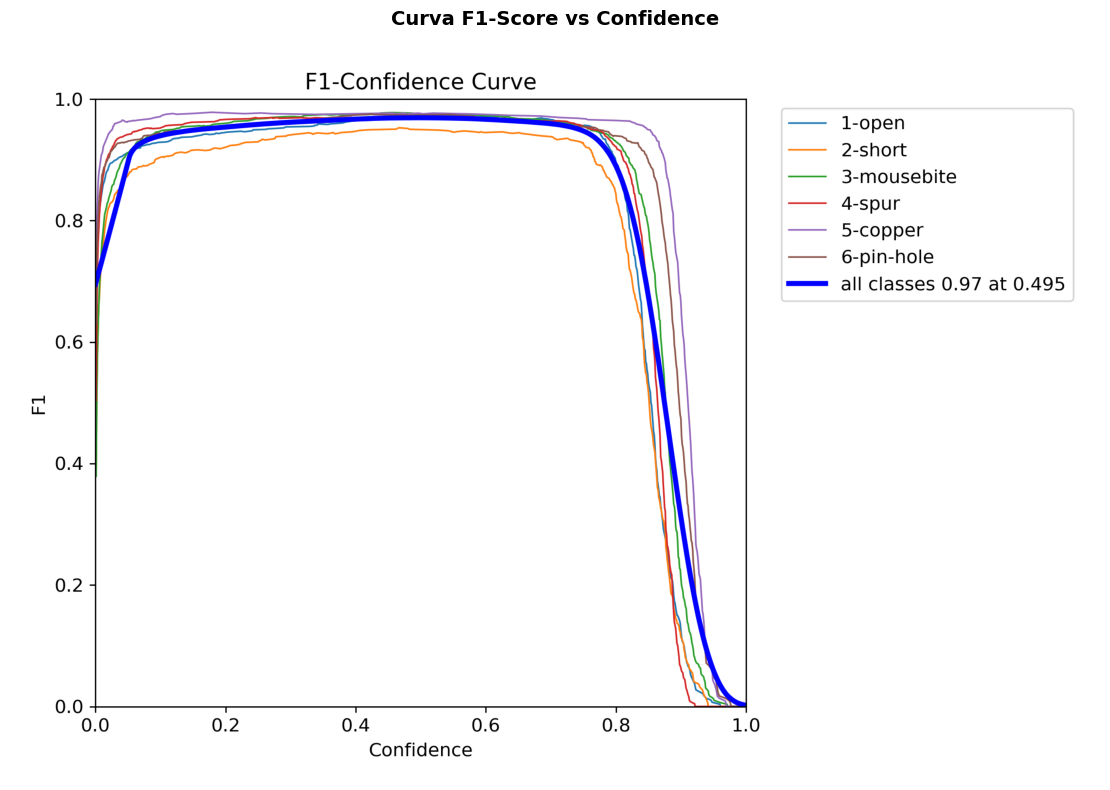

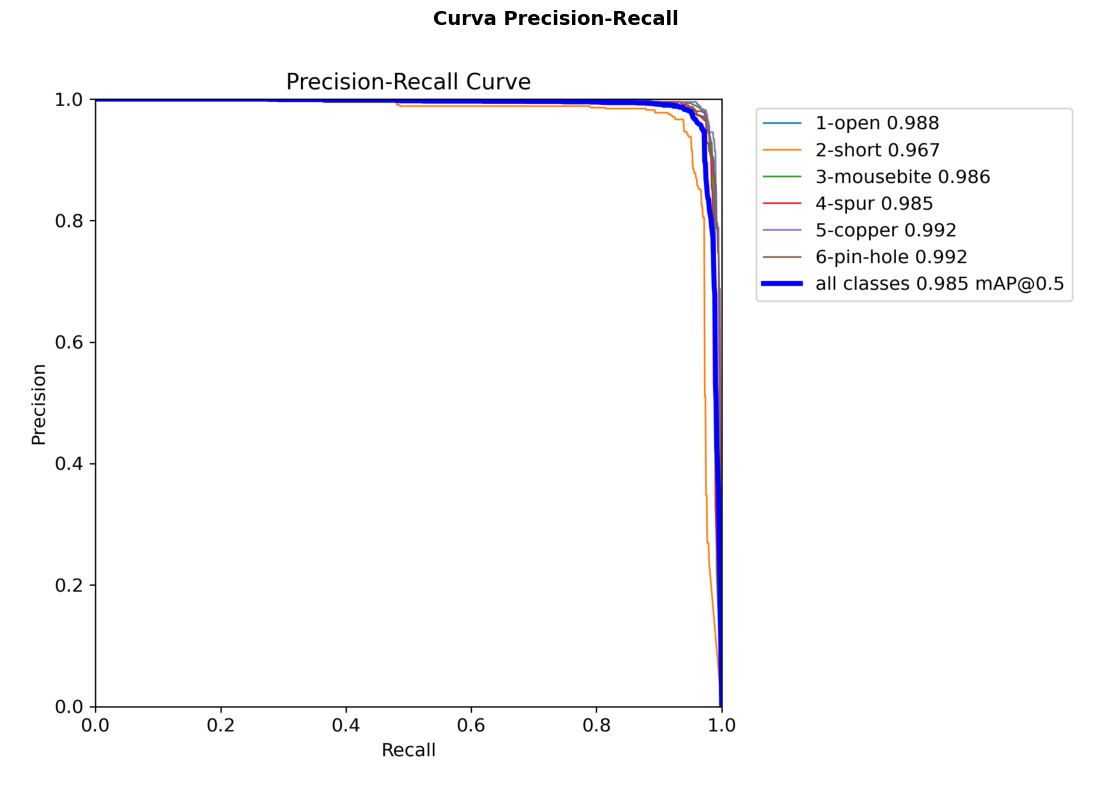

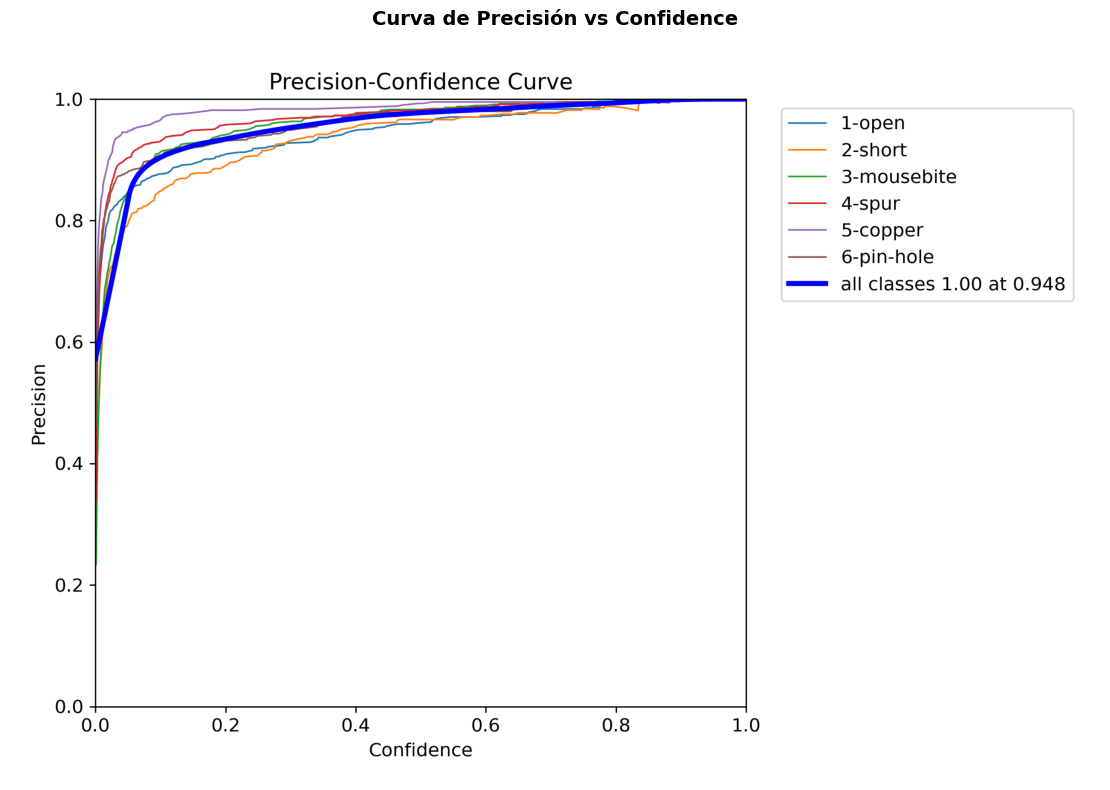

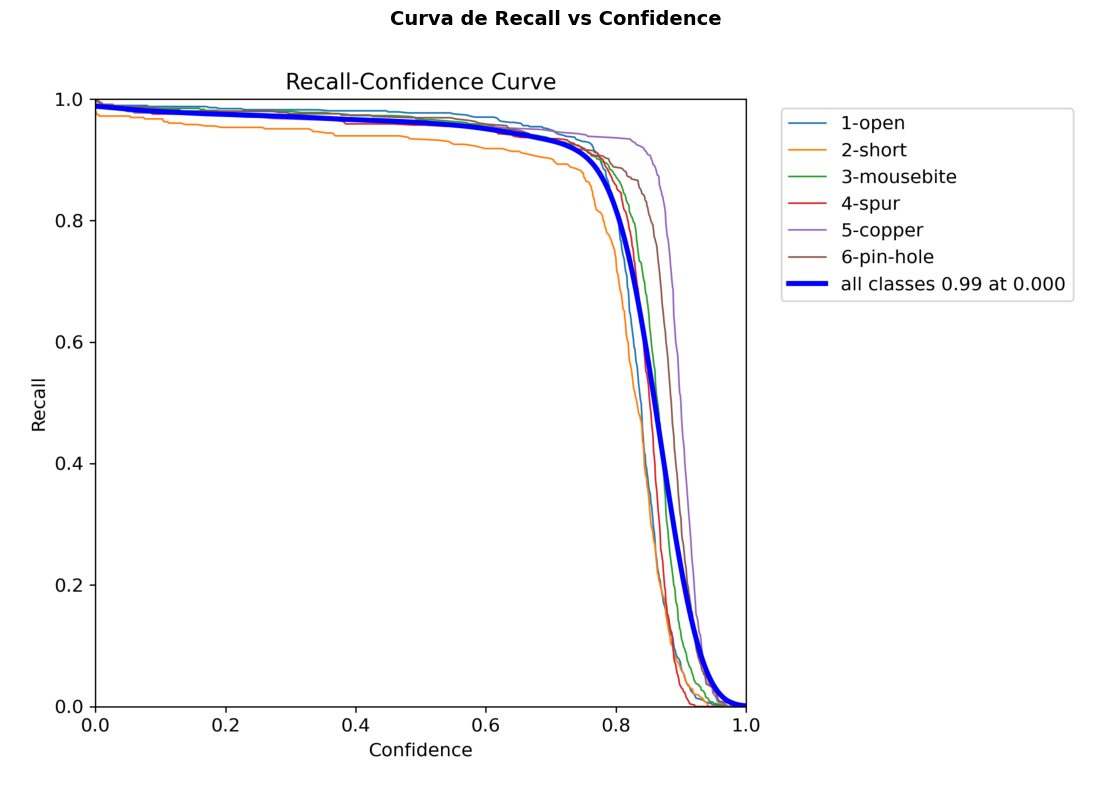

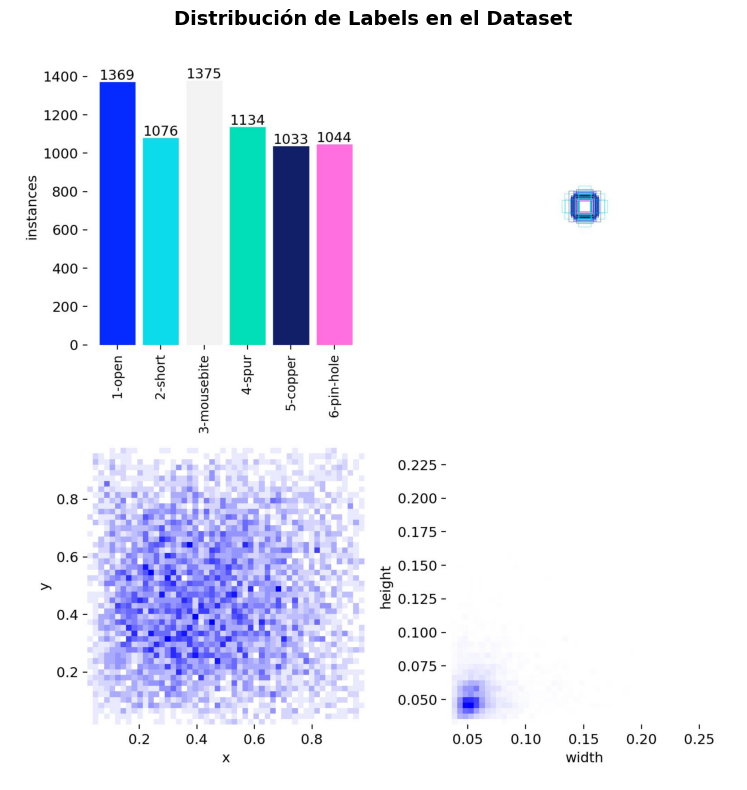


Total de métricas ploteadas: 8/8


In [60]:
# Plotear todas las métricas disponibles
plot_run_metrics(TRAIN_DIR)

---

## 4. Análisis de Resultados del Entrenamiento

### 4.1 Configuración del Experimento

**Modelo:** YOLOv8n (nano)  
**Épocas:** 100  
**Tamaño de imagen:** 640x640  
**Batch size:** 4  
**Dataset:** DeepPCB con 6 clases de defectos  
**Split:** 70% entrenamiento, 30% validación

**Clases detectadas:**
1. open (circuito abierto)
2. short (cortocircuito)
3. mousebite (mordida de ratón)
4. spur (espuela)
5. copper (cobre)
6. pin-hole (agujero de pin)

---

### 4.2 Resultados Principales

#### Métricas Finales (Época 100)

**Métricas de Precisión:**
- **Precision:** ~0.99 (99%)
- **Recall:** ~0.99 (99%)
- **mAP@0.5:** 0.985 (98.5%)
- **mAP@0.5:0.95:** ~0.75 (75%)
- **F1-Score óptimo:** 0.97 a confidence threshold de 0.495

**Pérdidas Finales:**
- **train/box_loss:** ~0.75 (baja y estable)
- **train/cls_loss:** ~0.40 (baja y convergida)
- **train/dfl_loss:** ~0.88 (convergida)
- **val/box_loss:** ~0.90 (cercana a train, buen ajuste)
- **val/cls_loss:** ~0.40 (similar a train)
- **val/dfl_loss:** ~0.88 (estable)

#### Rendimiento por Clase (mAP@0.5)

| Clase | AP@0.5 | Rendimiento |
|-------|--------|-------------|
| open | 0.988 | Excelente |
| short | 0.967 | Excelente |
| mousebite | 0.986 | Excelente |
| spur | 0.985 | Excelente |
| copper | 0.992 | Excelente |
| pin-hole | 0.992 | Excelente |
| **Promedio** | **0.985** | **Excelente** |

---

### 4.3 Análisis de la Matriz de Confusión

**Resultados de la Matriz Normalizada:**

- **open:** 98% de precisión (560/612 correctos, confusión mínima con short: 2%)
- **short:** 96% de precisión (411/452 correctos, algo de confusión con open)
- **mousebite:** 97% de precisión (572/604 correctos, excelente discriminación)
- **spur:** 97% de precisión (474/495 correctos, muy buen rendimiento)
- **copper:** 97% de precisión (427/435 correctos, casi perfecto)
- **pin-hole:** 98% de precisión (448/476 correctos, excelente detección)

**Observaciones principales:**
- Diagonal principal muy marcada: el modelo clasifica correctamente casi todas las clases
- Principal confusión: entre "open" y "short" (clases visualmente similares)
- Falsos positivos de background bajos (< 5% en todas las clases)
- No hay confusiones significativas entre clases distintas

---

### 4.4 Evolución del Entrenamiento

#### Fase Inicial (Épocas 0-20)
- **Losses:** Descenso rápido desde valores altos (~2.0) hasta ~1.0
- **mAP:** Incremento pronunciado desde 0.40 hasta 0.90
- **Aprendizaje:** Muy efectivo, el modelo aprende rápidamente los patrones básicos

#### Fase de Convergencia (Épocas 20-60)
- **Losses:** Descenso gradual y estabilización
- **mAP:** Alcanza plateau cerca de 0.98-0.99
- **Precision/Recall:** Ambas métricas superan el 95%

#### Fase Final (Épocas 60-100)
- **Losses:** Completamente estables, pequeñas oscilaciones normales
- **mAP:** Mantenida en ~0.985 con mínima variación
- **Conclusión:** Modelo ha convergido correctamente

**Indicadores de buen ajuste:**
- Las curvas de validación siguen de cerca las de entrenamiento
- No hay divergencia entre train/val losses (no overfitting)
- Gap pequeño y constante entre métricas de train y val (generalización correcta)

---

### 4.5 Análisis de Curvas de Rendimiento

#### Curva F1-Score vs Confidence
- **F1 máximo:** 0.97 alcanzado en confidence = 0.495
- **Rango óptimo:** Confidence entre 0.30-0.70 mantiene F1 > 0.90
- **Recomendación:** Usar threshold de 0.50 para balance óptimo precision-recall

#### Curva Precision-Recall
- **Área bajo la curva (mAP):** 0.985 - Excelente
- **Forma:** Curvas muy cercanas a esquina superior derecha (1,1)
- **Todas las clases:** Mantienen precision > 0.95 para recall > 0.95
- **Interpretación:** El modelo es igualmente bueno en precisión y sensibilidad

#### Curva Precision vs Confidence
- **Comportamiento:** Precision se mantiene alta (~1.0) desde confidence 0.50 en adelante
- **A confidence bajo (< 0.10):** Precision aún sobre 0.80, indicando pocas falsas alarmas

#### Curva Recall vs Confidence
- **Comportamiento:** Recall = 0.99 a confidence = 0.0 (detecta casi todo)
- **Decline gradual:** Mantiene recall > 0.90 hasta confidence ~0.80
- **Trade-off claro:** Aumentar confidence reduce recall moderadamente

---

### 4.6 Distribución del Dataset

**Balance de clases (training set):**
- 1-open: 1,369 instancias (clase más frecuente)
- 2-short: 1,076 instancias
- 3-mousebite: 1,375 instancias (segunda más frecuente)
- 4-spur: 1,134 instancias
- 5-copper: 1,033 instancias
- 6-pin-hole: 1,044 instancias

**Observaciones:**
- Dataset relativamente balanceado (variación < 25% entre clases)
- Distribución espacial uniforme en las imágenes (scatter plot centrado)
- Tamaños de bounding boxes pequeños (mayoría < 10% del tamaño de imagen)
- Objetos distribuidos por toda el área de la imagen (no concentrados)

---

### 4.7 Diagnóstico: Overfitting vs Underfitting

**Evaluación según criterios establecidos:**

| Criterio | Train | Val | Diagnóstico |
|----------|-------|-----|-------------|
| box_loss | 0.75 | 0.90 | Gap pequeño - OK |
| cls_loss | 0.40 | 0.40 | Prácticamente igual - Excelente |
| dfl_loss | 0.88 | 0.88 | Prácticamente igual - Excelente |
| mAP@0.5 | ~0.99 | 0.985 | Gap mínimo - Perfecto |

**Conclusión: BUEN AJUSTE**
- Losses de validación ligeramente superiores a entrenamiento
- No hay divergencia ni incremento de val_loss
- mAP muy alto en validación (98.5%)
- El modelo generaliza correctamente a datos no vistos

---

### 4.8 Conclusiones y Recomendaciones

#### Logros del Modelo

**EXCELENTE rendimiento general:**
- mAP@0.5 = 98.5% supera ampliamente el umbral de "bueno" (75%)
- Todas las clases tienen AP > 96.5% (muy balanceado)
- Precision y Recall ~99% (casi perfecto)
- Matriz de confusión con diagonal muy marcada

**Capacidad de generalización comprobada:**
- No hay signos de overfitting
- Pérdidas de validación estables
- Rendimiento consistente en todas las clases

#### Puntos a Considerar para Producción

**Configuración del threshold:**
- **Threshold recomendado: 0.50**
  - F1-Score: 0.97
  - Balance óptimo entre precision/recall
  
- **Threshold conservador: 0.70**
  - Si se prioriza evitar falsas alarmas (precision alta)
  - Recall ~0.95 aún excelente
  
- **Threshold sensible: 0.30**
  - Si es crítico detectar todos los defectos (recall alto)
  - Precision ~0.96 todavía muy buena



## 5. Evaluación Completa en TODAS las Imágenes de Validación

Ahora vamos a realizar inferencia sobre **todas** las imágenes del conjunto de validación, guardar los resultados y analizar el rendimiento global.

In [61]:
def run_inference_on_folder(model, folder_path, out_dir, conf=0.25, iou=0.7):
    """
    Ejecuta inferencia en todas las imágenes de una carpeta
    
    Args:
        model: Modelo YOLO cargado
        folder_path: Ruta a la carpeta con imágenes
        out_dir: Directorio de salida para guardar resultados
        conf: Confidence threshold
        iou: IoU threshold para NMS
    
    Returns:
        results_dict: Diccionario con estadísticas de la inferencia
    """
    # Crear directorio de salida
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(os.path.join(out_dir, 'visualizations'), exist_ok=True)
    os.makedirs(os.path.join(out_dir, 'predictions'), exist_ok=True)
    
    # Obtener todas las imágenes
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    image_paths = []
    for ext in image_extensions:
        image_paths.extend(glob.glob(os.path.join(folder_path, ext)))
    
    if not image_paths:
        print(f"❌ No se encontraron imágenes en {folder_path}")
        return None
    
    print(f"🔍 Encontradas {len(image_paths)} imágenes para procesar")
    print(f"📁 Guardando resultados en: {out_dir}")
    
    # Estadísticas
    total_detections = 0
    images_with_detections = 0
    all_confidences = []
    all_classes = []
    
    start_time = time.time()
    
    # Procesar cada imagen
    for idx, img_path in enumerate(image_paths, 1):
        try:
            # Realizar predicción
            results = model.predict(
                source=img_path,
                conf=conf,
                iou=iou,
                verbose=False
            )
            
            result = results[0]
            
            # Guardar visualización
            img_name = os.path.basename(img_path)
            img_name_no_ext = os.path.splitext(img_name)[0]
            
            # Guardar imagen con boxes
            result_img = result.plot()
            result_img_bgr = cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(
                os.path.join(out_dir, 'visualizations', f'{img_name_no_ext}_pred.jpg'),
                result_img_bgr
            )
            
            # Guardar predicciones en formato YOLO
            boxes = result.boxes
            if boxes is not None and len(boxes) > 0:
                images_with_detections += 1
                
                with open(os.path.join(out_dir, 'predictions', f'{img_name_no_ext}.txt'), 'w') as f:
                    for box in boxes:
                        # Extraer información
                        cls = int(box.cls[0].cpu().numpy())
                        conf_val = float(box.conf[0].cpu().numpy())
                        xywhn = box.xywhn[0].cpu().numpy()  # normalized xywh
                        
                        # Guardar en formato YOLO
                        f.write(f"{cls} {xywhn[0]:.6f} {xywhn[1]:.6f} {xywhn[2]:.6f} {xywhn[3]:.6f} {conf_val:.6f}\n")
                        
                        # Estadísticas
                        total_detections += 1
                        all_confidences.append(conf_val)
                        all_classes.append(cls)
            
            # Progreso
            if idx % 10 == 0 or idx == len(image_paths):
                elapsed = time.time() - start_time
                eta = (elapsed / idx) * (len(image_paths) - idx)
                print(f"   Progreso: {idx}/{len(image_paths)} ({idx/len(image_paths)*100:.1f}%) - ETA: {eta:.1f}s", end='\r')
        
        except Exception as e:
            print(f"\n⚠️ Error procesando {img_path}: {str(e)}")
    
    total_time = time.time() - start_time
    
    # Imprimir resumen
    print(f"\n\n{'='*70}")
    print(f"✅ INFERENCIA COMPLETADA")
    print(f"{'='*70}")
    print(f"📊 Total de imágenes procesadas: {len(image_paths)}")
    print(f"🎯 Imágenes con detecciones: {images_with_detections} ({images_with_detections/len(image_paths)*100:.1f}%)")
    print(f"🔍 Total de detecciones realizadas: {total_detections}")
    print(f"⏱️  Tiempo total: {total_time:.2f}s")
    print(f"⚡ Tiempo promedio por imagen: {total_time/len(image_paths):.3f}s")
    print(f"{'='*70}")
    
    # Estadísticas de confianza
    if all_confidences:
        print(f"\n📈 Estadísticas de Confianza:")
        print(f"   - Promedio: {np.mean(all_confidences):.4f}")
        print(f"   - Mediana: {np.median(all_confidences):.4f}")
        print(f"   - Mínima: {np.min(all_confidences):.4f}")
        print(f"   - Máxima: {np.max(all_confidences):.4f}")
        print(f"   - Desviación estándar: {np.std(all_confidences):.4f}")
    
    return {
        'total_images': len(image_paths),
        'images_with_detections': images_with_detections,
        'total_detections': total_detections,
        'total_time': total_time,
        'avg_time_per_image': total_time / len(image_paths),
        'confidences': all_confidences,
        'classes': all_classes,
        'image_paths': image_paths
    }

print("✅ Función de inferencia definida correctamente")

✅ Función de inferencia definida correctamente


### 5.1 Cargar el Modelo Entrenado

In [62]:
# Cargar el mejor modelo entrenado
if WEIGHTS_PATH and os.path.exists(WEIGHTS_PATH):
    model_eval = YOLO(WEIGHTS_PATH)
    print(f"✅ Modelo cargado exitosamente desde: {WEIGHTS_PATH}")
else:
    print("❌ ERROR: No se pudo cargar el modelo")
    print("   Verifica que el entrenamiento se haya completado correctamente")

✅ Modelo cargado exitosamente desde: detect\train2\weights\best.pt


### 5.2 Ejecutar Inferencia en Todas las Imágenes de Validación

In [63]:
# Definir rutas
VAL_IMAGES_DIR = PATH + 'val/images'
OUT_DIR = TRAIN_DIR + '/inference_val_all' if TRAIN_DIR else '/content/inference_val_all'

print(f"📂 Directorio de imágenes de validación: {VAL_IMAGES_DIR}")
print(f"💾 Directorio de salida: {OUT_DIR}")

# Ejecutar inferencia
results_stats = run_inference_on_folder(
    model=model_eval,
    folder_path=VAL_IMAGES_DIR,
    out_dir=OUT_DIR,
    conf=0.25,    # Confidence threshold
    iou=0.7       # IoU threshold para NMS
)

📂 Directorio de imágenes de validación: Data/val/images
💾 Directorio de salida: detect\train2/inference_val_all
🔍 Encontradas 900 imágenes para procesar
📁 Guardando resultados en: detect\train2/inference_val_all
   Progreso: 900/900 (100.0%) - ETA: 0.0s

✅ INFERENCIA COMPLETADA
📊 Total de imágenes procesadas: 900
🎯 Imágenes con detecciones: 900 (100.0%)
🔍 Total de detecciones realizadas: 6246
⏱️  Tiempo total: 25.06s
⚡ Tiempo promedio por imagen: 0.028s

📈 Estadísticas de Confianza:
   - Promedio: 0.8219
   - Mediana: 0.8590
   - Mínima: 0.2502
   - Máxima: 0.9751
   - Desviación estándar: 0.1324


### 5.3 Análisis de Resultados

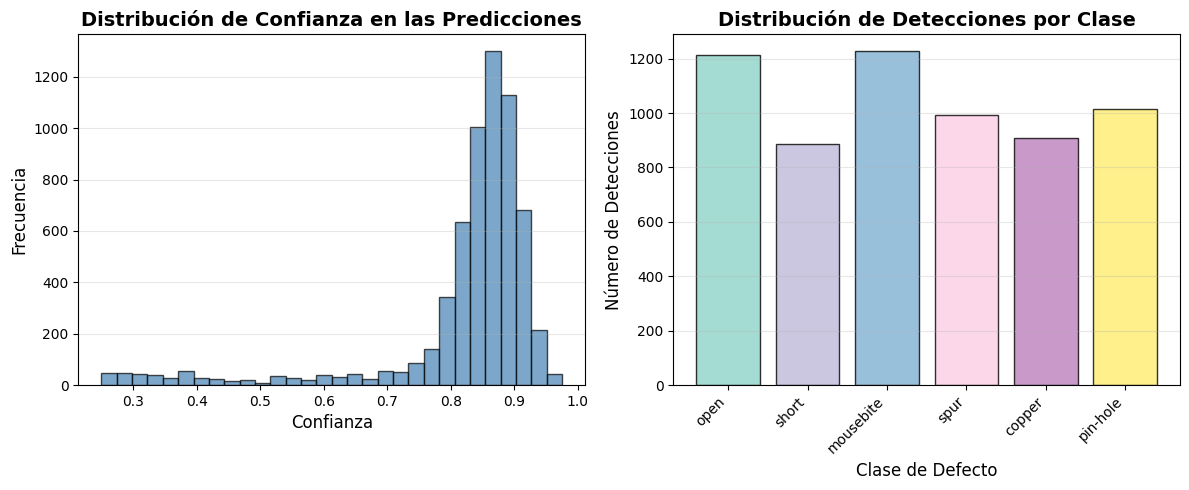


📊 DETECCIONES POR CLASE DE DEFECTO
Clase           Cantidad     Porcentaje  
----------------------------------------------------------------------
open            1214          19.44%
short           886           14.19%
mousebite       1228          19.66%
spur            994           15.91%
copper          910           14.57%
pin-hole        1014          16.23%
TOTAL           6246         100.00%


In [64]:
if results_stats and results_stats['confidences']:
    # 1. Histograma de confianzas
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(results_stats['confidences'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    plt.xlabel('Confianza', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.title('Distribución de Confianza en las Predicciones', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    # 2. Detecciones por clase
    plt.subplot(1, 2, 2)
    dict_classes = {0: 'open', 1: 'short', 2: 'mousebite', 3: 'spur', 4: 'copper', 5: 'pin-hole'}
    class_counts = np.bincount(results_stats['classes'], minlength=6)
    class_names = [dict_classes[i] for i in range(6)]
    
    colors = plt.cm.Set3(np.linspace(0, 1, 6))
    plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black')
    plt.xlabel('Clase de Defecto', fontsize=12)
    plt.ylabel('Número de Detecciones', fontsize=12)
    plt.title('Distribución de Detecciones por Clase', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Tabla resumen por clase
    print(f"\n{'='*70}")
    print("📊 DETECCIONES POR CLASE DE DEFECTO")
    print(f"{'='*70}")
    print(f"{'Clase':<15} {'Cantidad':<12} {'Porcentaje':<12}")
    print(f"{'-'*70}")
    for i in range(6):
        count = class_counts[i]
        percentage = (count / results_stats['total_detections'] * 100) if results_stats['total_detections'] > 0 else 0
        print(f"{class_names[i]:<15} {count:<12} {percentage:>6.2f}%")
    print(f"{'='*70}")
    print(f"{'TOTAL':<15} {results_stats['total_detections']:<12} 100.00%")
    print(f"{'='*70}")
else:
    print("⚠️ No hay datos de confianza para analizar")

### 5.4 Visualización de Ejemplos Aleatorios

Mostramos un grid con predicciones aleatorias del conjunto de validación.

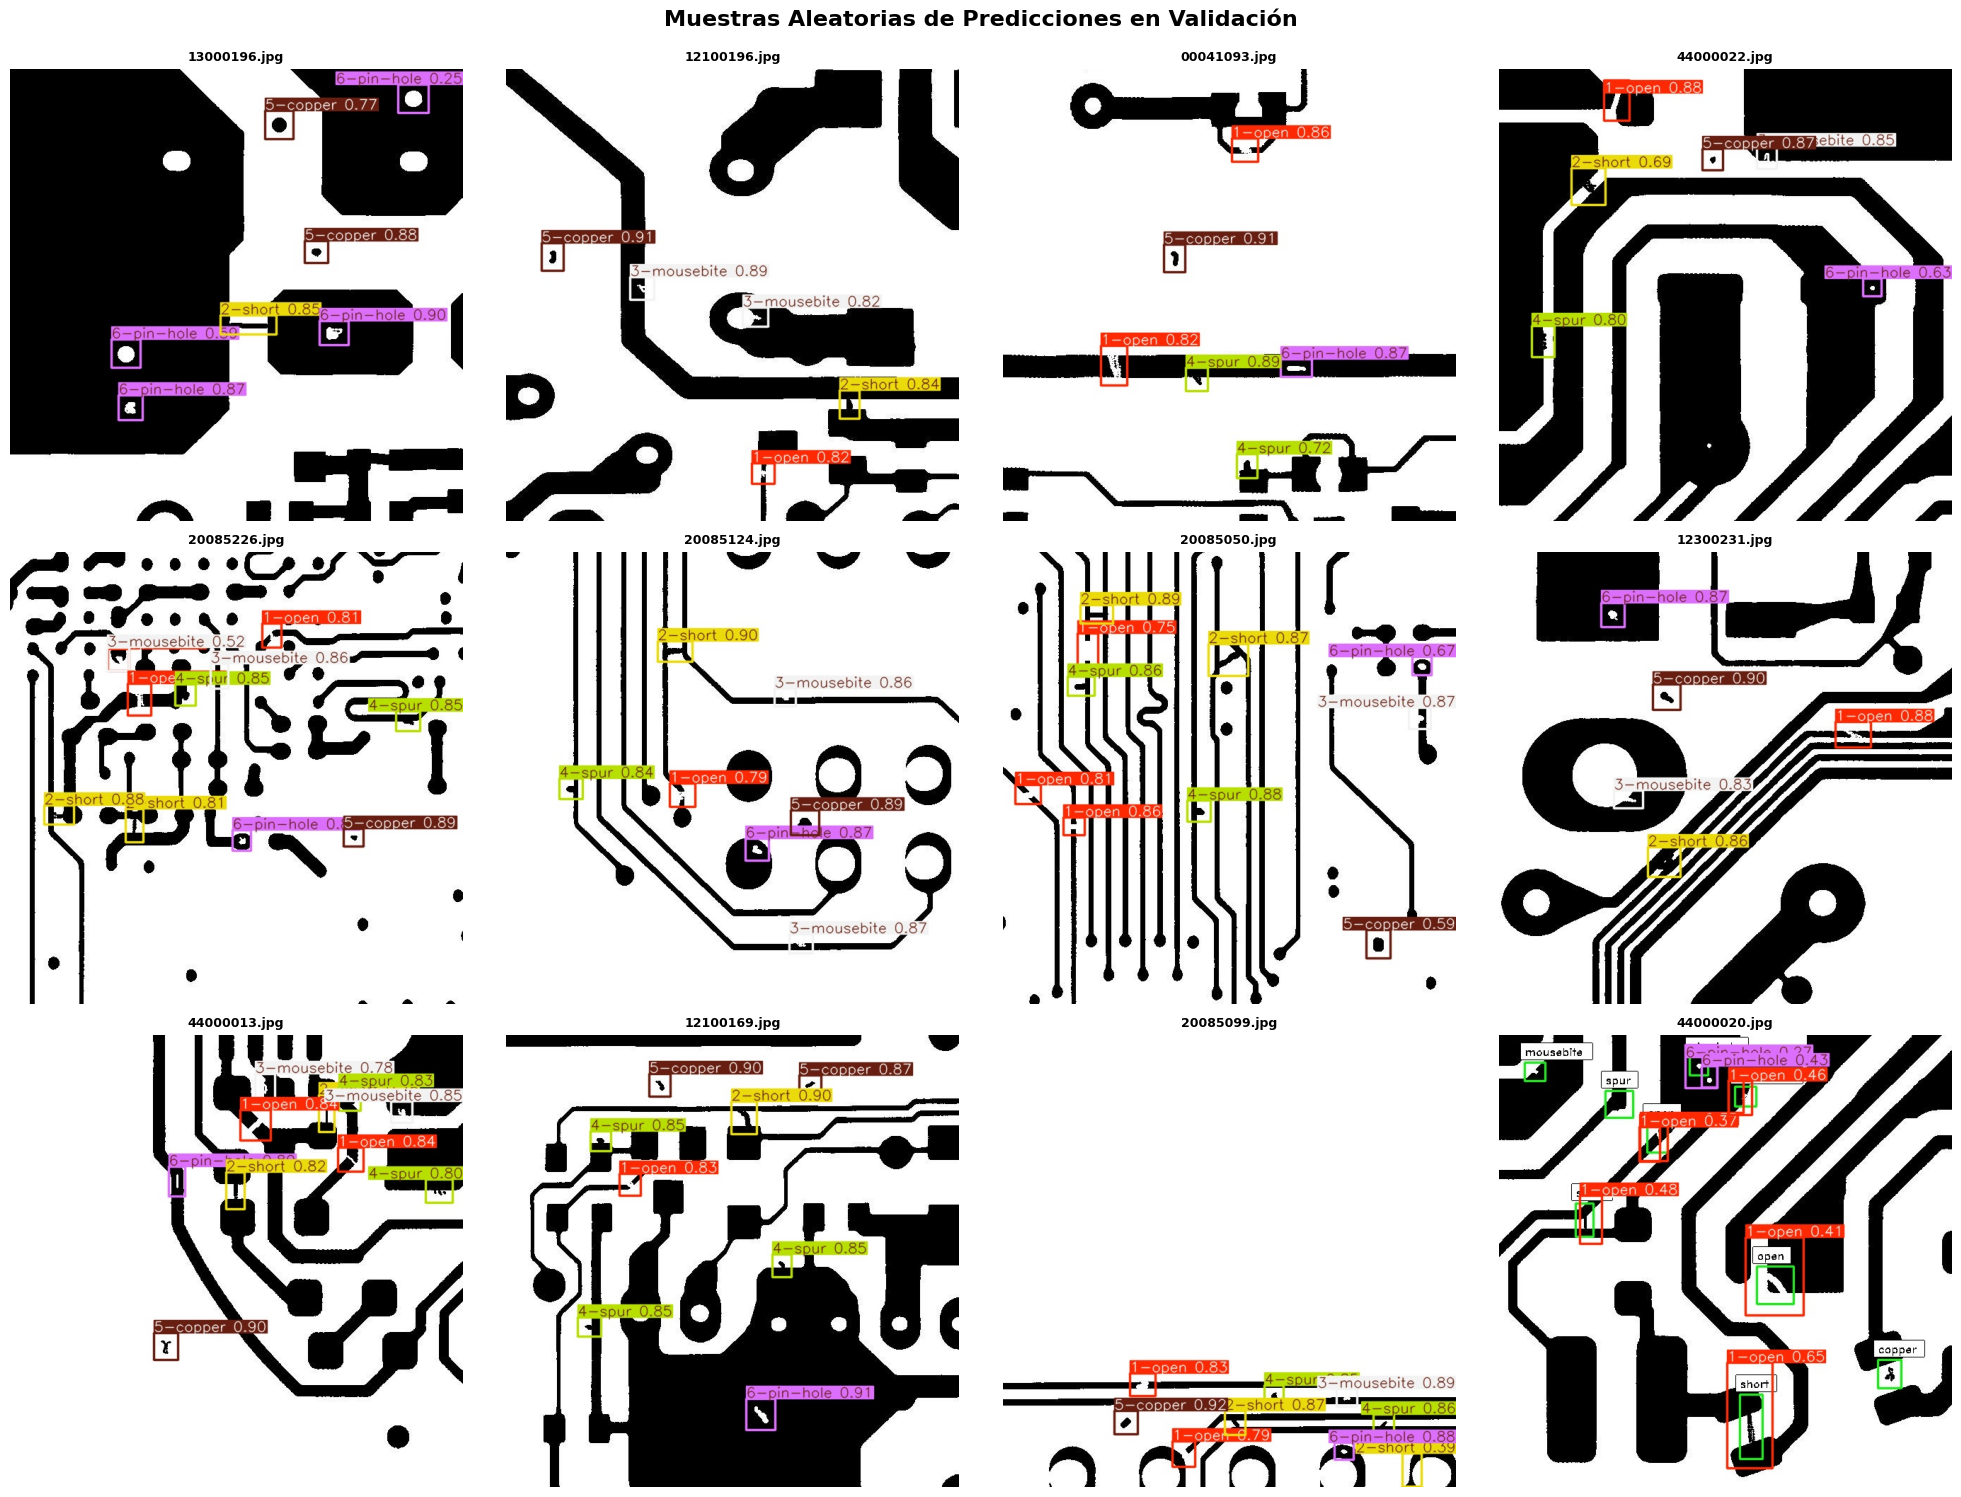

In [65]:
if results_stats and results_stats['image_paths']:
    # Seleccionar 12 imágenes aleatorias
    num_samples = min(12, len(results_stats['image_paths']))
    random.seed(42)
    sample_paths = random.sample(results_stats['image_paths'], num_samples)
    
    # Cargar visualizaciones guardadas
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.ravel()
    
    for idx, img_path in enumerate(sample_paths):
        if idx >= len(axes):
            break
        
        # Obtener ruta de la visualización guardada
        img_name = os.path.basename(img_path)
        img_name_no_ext = os.path.splitext(img_name)[0]
        vis_path = os.path.join(OUT_DIR, 'visualizations', f'{img_name_no_ext}_pred.jpg')
        
        if os.path.exists(vis_path):
            img = cv2.imread(vis_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img)
            axes[idx].axis('off')
            axes[idx].set_title(f'{img_name}', fontsize=9, fontweight='bold')
        else:
            axes[idx].text(0.5, 0.5, 'No disponible', ha='center', va='center')
            axes[idx].axis('off')
    
    # Ocultar ejes vacíos
    for idx in range(num_samples, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Muestras Aleatorias de Predicciones en Validación', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay imágenes para visualizar")

### 5.5 Descarga de Resultados (Opcional para Colab)

Si estás ejecutando en Google Colab, puedes descargar los resultados completos.

In [ ]:
# Opcional: Comprimir y descargar resultados (solo en Google Colab)
try:
    from google.colab import files
    
    # Comprimir carpeta de resultados
    zip_filename = 'inference_results_all_validation.zip'
    shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', OUT_DIR)
    
    print(f"Resultados comprimidos en: {zip_filename}")
    print("Iniciando descarga...")
    
    files.download(zip_filename)
    
    print("Descarga completada")
except ImportError:
    print("No estás en Google Colab. Los resultados están guardados en:")
    print(f"   {OUT_DIR}")
except Exception as e:
    print(f"Error al descargar: {str(e)}")
    print(f"Los resultados están disponibles en: {OUT_DIR}")

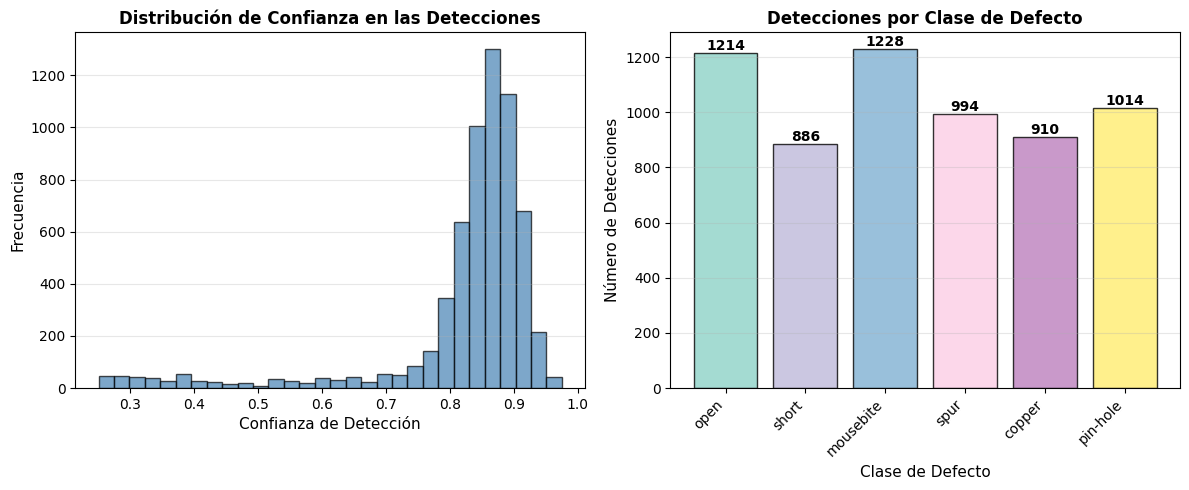


📊 Resumen de Detecciones por Clase:
  0: open            → 1214 detecciones (19.44%)
  1: short           →  886 detecciones (14.19%)
  2: mousebite       → 1228 detecciones (19.66%)
  3: spur            →  994 detecciones (15.91%)
  4: copper          →  910 detecciones (14.57%)
  5: pin-hole        → 1014 detecciones (16.23%)


In [66]:
if results_stats and results_stats['confidences']:
    # Histograma de confianzas
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(results_stats['confidences'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    plt.xlabel('Confianza de Detección', fontsize=11)
    plt.ylabel('Frecuencia', fontsize=11)
    plt.title('Distribución de Confianza en las Detecciones', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    # Detecciones por clase
    plt.subplot(1, 2, 2)
    class_counts = np.bincount(results_stats['classes'], minlength=6)
    class_names = ['open', 'short', 'mousebite', 'spur', 'copper', 'pin-hole']
    colors_bar = plt.cm.Set3(np.linspace(0, 1, 6))
    
    bars = plt.bar(class_names, class_counts, color=colors_bar, alpha=0.8, edgecolor='black')
    plt.xlabel('Clase de Defecto', fontsize=11)
    plt.ylabel('Número de Detecciones', fontsize=11)
    plt.title('Detecciones por Clase de Defecto', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Añadir valores sobre las barras
    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        if count > 0:
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(count)}',
                    ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Tabla resumen por clase
    print("\n📊 Resumen de Detecciones por Clase:")
    print("="*60)
    for i, (name, count) in enumerate(zip(class_names, class_counts)):
        percentage = (count / results_stats['total_detections'] * 100) if results_stats['total_detections'] > 0 else 0
        print(f"  {i}: {name:15s} → {count:4d} detecciones ({percentage:5.2f}%)")
    print("="*60)
else:
    print("⚠️ No hay resultados para analizar")